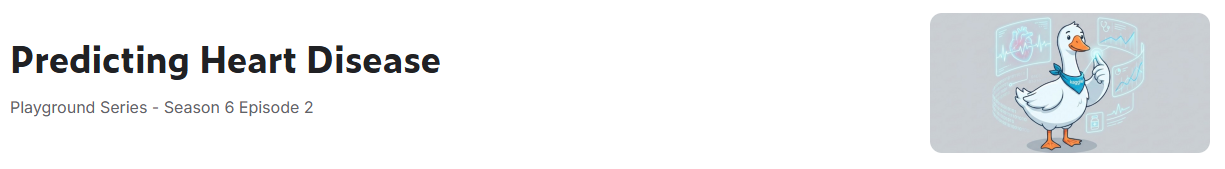

https://www.kaggle.com/competitions/playground-series-s6e2/overview

# **[0] Data Info**

<pre>
id              : ID
age             : 나이
sex             : 성별
chest pain type : 흉통 유형
bp              : 혈압
cholesterol     : 콜레스테롤
fbs over 120    : 공복 혈당 120 초과 여부
ekg results     : 심전도 결과
max hr          : 최대 심박수
exercise angina : 운동 유발 협심증
st depression   : ST 분절 하강
slope of st     : ST 분절 경사
number of vessels fluro : 혈관 조영술상 혈관 수
thallium        : 탈륨 검사 결과
heart disease   : 심장병

In [1]:
from sklearn import set_config
set_config(display="text")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')


#----------차트 속성 (한글처리/그리드)
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False



#----------문제/답 분리
from sklearn.model_selection import train_test_split 


#----------분류모델
from sklearn.linear_model import LogisticRegression   #선형모델 
from sklearn.ensemble import RandomForestClassifier   #트리모델

#----------모델결합(Ensembles)
from sklearn.ensemble import VotingClassifier, VotingRegressor   #앙상블


#----------평가 매트릭스
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, classification_report


#----------교차검증
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate


#----------인코딩(글자->숫자)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


#----------정규화(스케일링)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler 


#----------차원 축소
from sklearn.decomposition import PCA 

# **[1] Data Load**
* target : heart disease

In [3]:
train = pd.read_csv("../../Datas/#disease/train.csv") 
test = pd.read_csv("../../Datas/#disease/test.csv")
sub = pd.read_csv("../../Datas/#disease/sample_submission.csv")

### 컬럼 소문자 변경

In [4]:
train.columns = train.columns.str.lower()
test.columns = test.columns.str.lower()

### 컬럼 이름 변경

In [5]:
train.columns

Index(['id', 'age', 'sex', 'chest pain type', 'bp', 'cholesterol',
       'fbs over 120', 'ekg results', 'max hr', 'exercise angina',
       'st depression', 'slope of st', 'number of vessels fluro', 'thallium',
       'heart disease'],
      dtype='str')

<pre>
'ID', '나이', '성별', '흉통 유형', '혈압', '콜레스테롤', '공복 혈당 120 초과 여부', '심전도 결과', '최대 심박수', '운동 유발 협심증', 'ST 분절 하강', 'ST 분절 경사', '혈관 조영술상 혈관 수', '탈륨 검사 결과', '심장병'
    
'id', 'age', 'sex', 'chest pain type', 'bp', 'cholesterol', 'fbs over 120', 'ekg results', 'max hr', 'exercise angina', 'st depression', 'slope of st', 'number of vessels fluro', 'thallium', 'heart disease'

In [6]:
train = train.rename(columns={'chest pain type':'c_pain',
                              'cholesterol' : 'chol',
                              'fbs over 120': 'fbs',
                              'ekg results' : 'ekg',
                              'max hr' : 'hr', 
                              'exercise angina' : 'angina', 
                              'st depression' : 'st_d',
                              'slope of st' : 'sl_s',
                              'number of vessels fluro' : 'vessels'})

test = test.rename(columns={'chest pain type':'c_pain',
                              'cholesterol' : 'chol',
                              'fbs over 120': 'fbs',
                              'ekg results' : 'ekg',
                              'max hr' : 'hr', 
                              'exercise angina' : 'angina', 
                              'st depression' : 'st_d',
                              'slope of st' : 'sl_s',
                              'number of vessels fluro' : 'vessels'})

In [7]:
train.head(2)

,id,age,sex,c_pain,bp,chol,fbs,ekg,hr,angina,st_d,sl_s,vessels,thallium,heart disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             630000 non-null  int64  
 1   age            630000 non-null  int64  
 2   sex            630000 non-null  int64  
 3   c_pain         630000 non-null  int64  
 4   bp             630000 non-null  int64  
 5   chol           630000 non-null  int64  
 6   fbs            630000 non-null  int64  
 7   ekg            630000 non-null  int64  
 8   hr             630000 non-null  int64  
 9   angina         630000 non-null  int64  
 10  st_d           630000 non-null  float64
 11  sl_s           630000 non-null  int64  
 12  vessels        630000 non-null  int64  
 13  thallium       630000 non-null  int64  
 14  heart disease  630000 non-null  str    
dtypes: float64(1), int64(13), str(1)
memory usage: 72.1 MB


In [9]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 14 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   id        270000 non-null  int64  
 1   age       270000 non-null  int64  
 2   sex       270000 non-null  int64  
 3   c_pain    270000 non-null  int64  
 4   bp        270000 non-null  int64  
 5   chol      270000 non-null  int64  
 6   fbs       270000 non-null  int64  
 7   ekg       270000 non-null  int64  
 8   hr        270000 non-null  int64  
 9   angina    270000 non-null  int64  
 10  st_d      270000 non-null  float64
 11  sl_s      270000 non-null  int64  
 12  vessels   270000 non-null  int64  
 13  thallium  270000 non-null  int64  
dtypes: float64(1), int64(13)
memory usage: 28.8 MB


### 인코딩

In [10]:
train['heart disease'].value_counts()

heart disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [11]:
train['heart disease'] = train['heart disease'].map({"Presence":0, "Absence":1})
train.head(2)

,id,age,sex,c_pain,bp,chol,fbs,ekg,hr,angina,st_d,sl_s,vessels,thallium,heart disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,0
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,1


In [12]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   id             630000 non-null  int64  
 1   age            630000 non-null  int64  
 2   sex            630000 non-null  int64  
 3   c_pain         630000 non-null  int64  
 4   bp             630000 non-null  int64  
 5   chol           630000 non-null  int64  
 6   fbs            630000 non-null  int64  
 7   ekg            630000 non-null  int64  
 8   hr             630000 non-null  int64  
 9   angina         630000 non-null  int64  
 10  st_d           630000 non-null  float64
 11  sl_s           630000 non-null  int64  
 12  vessels        630000 non-null  int64  
 13  thallium       630000 non-null  int64  
 14  heart disease  630000 non-null  int64  
dtypes: float64(1), int64(14)
memory usage: 72.1 MB


In [13]:
train["id"].duplicated().sum()
test["id"].duplicated().sum()

np.int64(0)

# **[2] EDA(Exploratory Data Analysis)**

## **상관분석**

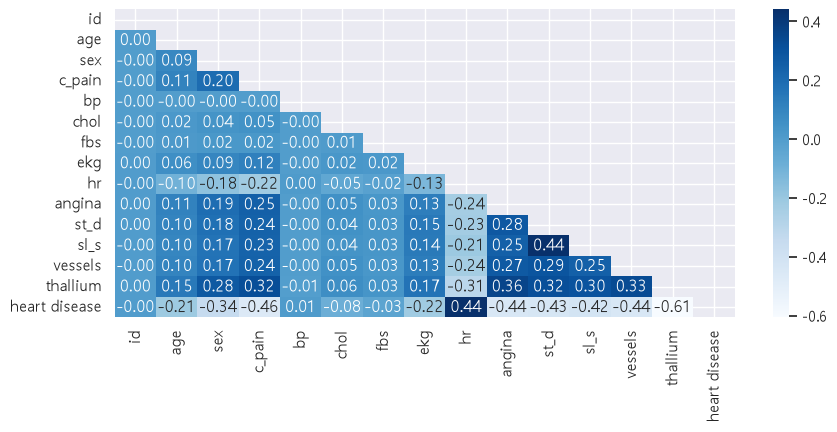

In [14]:
plt.figure(figsize=(10, 4))

# 반쪽으로 보기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)    #.2f = 소수점 2자리까지~ (d=숫자로)
plt.show()

> <b> thallium, st_d, hr, c_pain & heart disease 

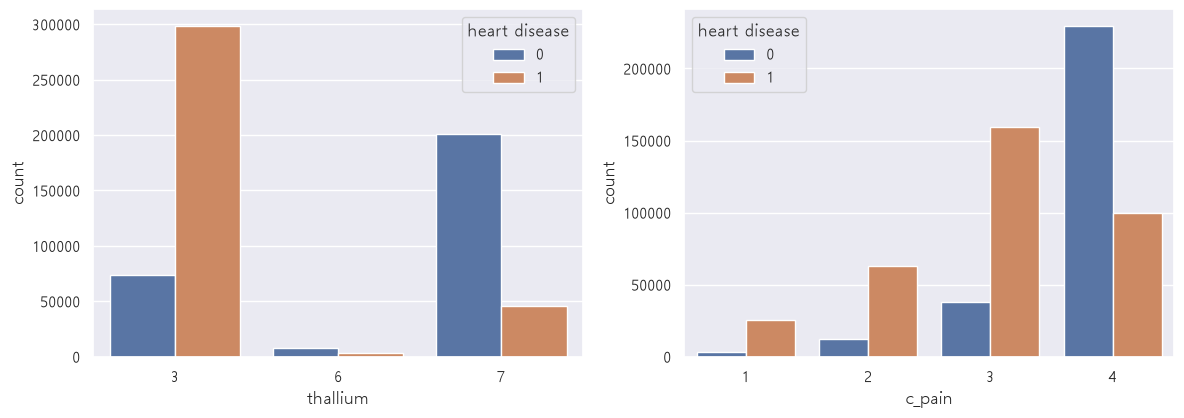

In [15]:
plt.figure(figsize=(12,8))


plt.subplot(2, 2, 1)
sns.countplot(x="thallium", hue="heart disease", data=train)

plt.subplot(2, 2, 2) 
sns.countplot(x="c_pain", hue="heart disease", data=train)

plt.tight_layout()
plt.show()

## **시각화 hist()**
* 데이터 분포도 확인(왜도, 첨도, 정규분포)

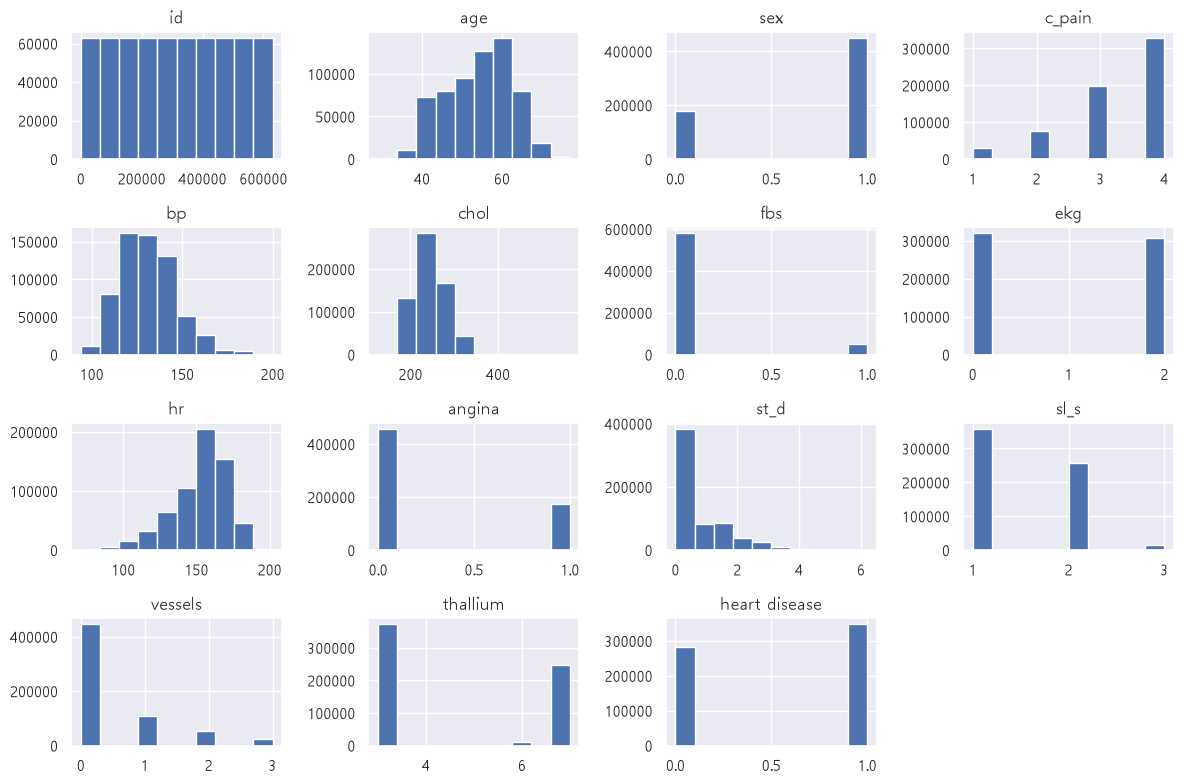

In [16]:
train.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [17]:
train

,id,age,sex,c_pain,bp,chol,fbs,ekg,hr,angina,st_d,sl_s,vessels,thallium,heart disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,0
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,1
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,1
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,1
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,1
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,1
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,0
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,0


# **[3] 공통함수**

In [18]:
def myscore(X_train7, y_train7, X_test3, y_test3, model=None) :
    if model is None : 
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    acc = accuracy_score(y_test3, pred)
    print( f"acc : {acc:.4f}" )

In [19]:
def myscore222(df,  model=None, MY_TARGET="heart disease") :
    X = df.drop(columns=['heart disease'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.2, random_state=1234, shuffle=True)

    if model is None : 
        #LogisticRegression , RandomForestClassifier
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    

    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred)
    precision = precision_score(y_test3, pred)
    recall    = recall_score(y_test3, pred)    
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )
    
    cm = confusion_matrix(y_test3, pred)
    print( cm )
    
    #-------------------------------------------------proba
    # proba = model.predict_proba(X_test3)
    # proba_p = proba[:,1]
    #print(proba_p)
    
    # precision, recall, th = precision_recall_curve(y_test3, proba_p)
    # #print(precision, recall, th)
    # #print(len(precision), len(recall), len(th))

    # plt.figure(figsize=(8,2))
    # plt.plot(th, precision[:len(th)], label="precision")
    # plt.plot(th, recall[:len(th)], label="recall")
    # plt.legend()
    # plt.title("precision_reacall_curv")
    # plt.show()

    #-------------------------------------------------proba : roc
    # roc = roc_auc_score(y_test3, proba_p)
    # print( f"roc auc score : {roc:.4f}" )
    # fpr, tpr, th = roc_curve(y_test3, proba_p)

    # plt.figure(figsize=(8,2))
    # plt.plot(fpr, tpr)
    # plt.plot([0, 1], [0, 1], 'k--')
    # plt.title("roc_curve")
    # plt.xlabel("False Positive Rate (FPR)")
    # plt.ylabel("True Positive Rate (TPR) == recall")
    # plt.show()       
    
    return model

In [20]:
def myscore_roc(df, model=None, MY_TARGET="heart disease") :
    
    X = df.drop(columns=[MY_TARGET])
    y = df[MY_TARGET]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=1234,
        shuffle=True,
        stratify=y
    )
    
    if model is None :
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    
    print(model.__class__.__name__)
    
    model.fit(X_train, y_train)
    
    proba = model.predict_proba(X_test)[:, 1]
    
    roc = roc_auc_score(y_test, proba)
    
    print(f"roc_auc : {roc:.4f}")
    
    return model

# <font color=darkorange> **※기본점수※**
* f1 : 0.8949 / <b> roc auc score : 0.9488

In [21]:
res = myscore222(train)

RandomForestClassifier
acc : 0.8832  f1 : 0.8949  precision : 0.8898  recall : 0.8999
[[48641  7755]
 [ 6964 62640]]


In [22]:
res = myscore_roc(train)

RandomForestClassifier
roc_auc : 0.9488


# **[4] 이상치 확인**

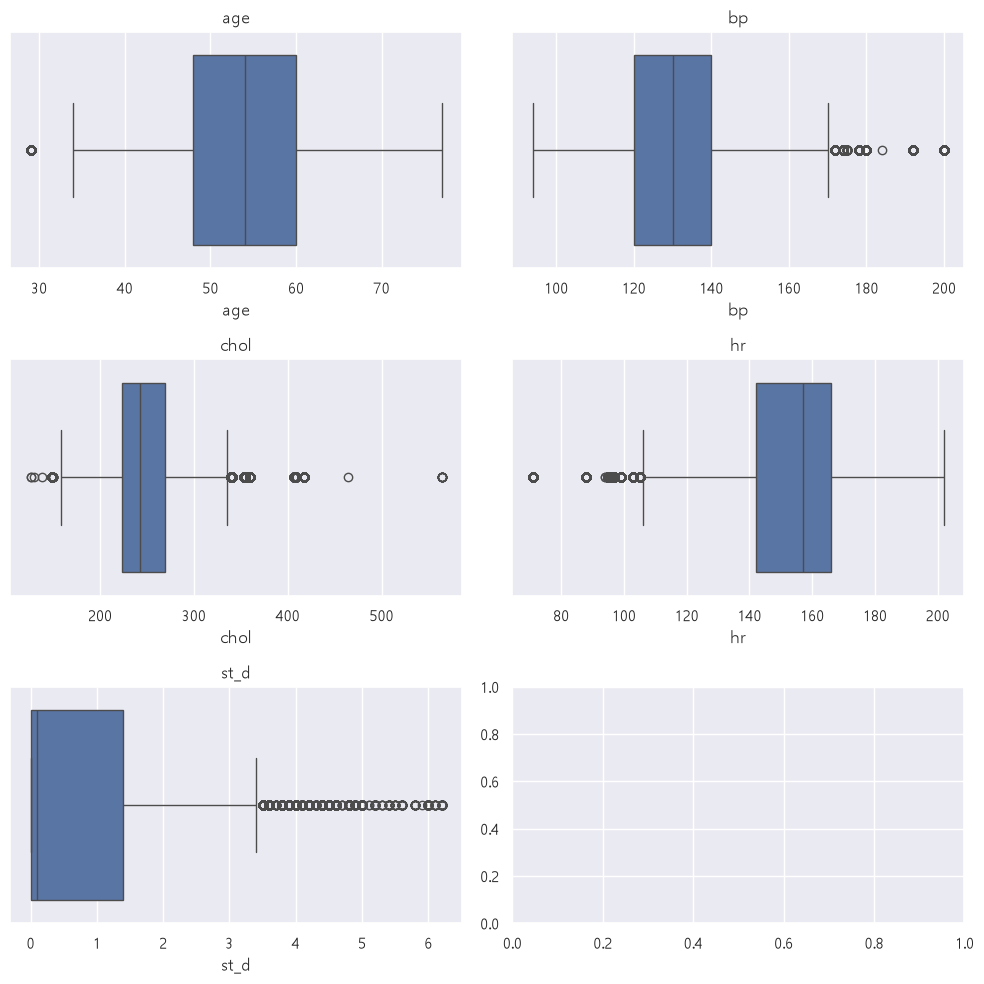

In [23]:
fig, axes = plt.subplots(3, 2, figsize=(10, 10))

col_list = ['age', 'bp', 'chol', 'hr', 'st_d']

for i, col in enumerate(col_list):
    row = i // 2
    col_num = i % 2
    
    sns.boxplot(x=train[col], ax=axes[row][col_num])
    axes[row][col_num].set_title(col)

plt.tight_layout()
plt.show()

In [24]:
col_list = ['age', 'bp', 'chol', 'hr', 'st_d']

for col in col_list:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier = train[(train[col] < lower) | (train[col] > upper)]
    
    print(f"{col} : {len(outlier)}")

age : 1048
bp : 9011
chol : 2194
hr : 14246
st_d : 9971


# <font color=darkorange> **※outlier 제거 TEST 점수※**
* **age, bp : 9493**
* 일단 보류

In [25]:
col_list = ['age', 'bp', 'chol', 'hr', 'st_d']

for col in col_list:

    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    idx_list = train[
        (train[col] < lower) |
        (train[col] > upper)
    ].index

    traincp = train.copy()
    traincp = traincp.drop(idx_list)

    print(f"\n===== {col} =====")
    print(f"하한 : {lower:.2f}")
    print(f"상한 : {upper:.2f}")
    print(f"삭제 행 : {len(idx_list)}")

    myscore_roc(traincp)


===== age =====
하한 : 30.00
상한 : 78.00
삭제 행 : 1048
RandomForestClassifier
roc_auc : 0.9493

===== bp =====
하한 : 90.00
상한 : 170.00
삭제 행 : 9011
RandomForestClassifier
roc_auc : 0.9493

===== chol =====
하한 : 154.00
상한 : 338.00
삭제 행 : 2194
RandomForestClassifier
roc_auc : 0.9488

===== hr =====
하한 : 106.00
상한 : 202.00
삭제 행 : 14246
RandomForestClassifier
roc_auc : 0.9469

===== st_d =====
하한 : -2.10
상한 : 3.50
삭제 행 : 9971
RandomForestClassifier
roc_auc : 0.9482


# **[5] 모델교체 & 피쳐 중요도**

In [26]:
from lightgbm import LGBMRegressor, LGBMClassifier
model = LGBMClassifier()

LGBMClassifier
[LightGBM] [Info] Number of positive: 278037, number of negative: 225963
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.551661 -> initscore=0.207383
[LightGBM] [Info] Start training from score 0.207383
roc_auc : 0.9546


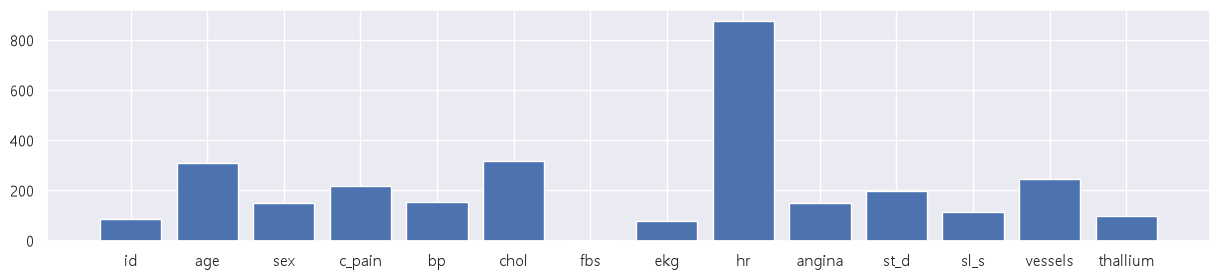

In [27]:
lgb = LGBMClassifier()

model = myscore_roc(train, lgb)
imp = model.feature_importances_

plt.figure(figsize=(15,3))

X = train.drop(columns=['heart disease'])
plt.bar(X.columns, imp, label="블루")
plt.tight_layout
plt.show()

In [28]:
traincp = train.copy()
traincp = traincp.set_index('id')
traincp.head()

#traincp = traincp.reset_index()

,age,sex,c_pain,bp,chol,fbs,ekg,hr,angina,st_d,sl_s,vessels,thallium,heart disease
id,,,,,,,,,,,,,,
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,0
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,1
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,1
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,1
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,0


# <font color=darkorange> **※피쳐별 TEST 점수※**
* 변수별 큰 차이와 영향은 없다

In [29]:
col_list = ['fbs', 'sex', 'ekg', 'thallium']

for col in col_list:

    traincp = train.copy()

    traincp = traincp.drop(columns=[col])

    print(f"\n===== {col} 제거 =====")

    lgb = LGBMClassifier(verbose=-1)
    myscore_roc(traincp, lgb)


===== fbs 제거 =====
LGBMClassifier
roc_auc : 0.9545

===== sex 제거 =====
LGBMClassifier
roc_auc : 0.9515

===== ekg 제거 =====
LGBMClassifier
roc_auc : 0.9540

===== thallium 제거 =====
LGBMClassifier
roc_auc : 0.9405


# **[6] 교차검증**

In [30]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier

X = train.drop(columns=['heart disease'])
y = train['heart disease']

lgb = LGBMClassifier(verbose=-1)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1234
)

scores = cross_val_score(
    lgb,
    X,
    y,
    cv=skf,
    scoring='roc_auc'
)

print("각 Fold ROC-AUC :", scores)
print("평균 ROC-AUC :", scores.mean())

각 Fold ROC-AUC : [0.9536123  0.95570711 0.95440493 0.95409681 0.95570806]
평균 ROC-AUC : 0.9547058420035253


# **[7] 모델튜닝**

In [31]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from lightgbm import LGBMClassifier

X = train.drop(columns=['heart disease'])
y = train['heart disease']

lgb = LGBMClassifier(
    verbose=-1,
    random_state=1234
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1234
)

params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 50]
}

grid = GridSearchCV(
    estimator=lgb,
    param_grid=params,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X, y)

print("최적 파라미터 :", grid.best_params_)
print("최고 ROC-AUC :", grid.best_score_)

최적 파라미터 : {'learning_rate': 0.1, 'n_estimators': 200, 'num_leaves': 31}
최고 ROC-AUC : 0.9550332896506235


In [32]:
lgb_best = LGBMClassifier(
    learning_rate=0.1,
    n_estimators=200,
    num_leaves=31,
    verbose=-1,
    random_state=1234
)

model = myscore_roc(train, lgb_best)

LGBMClassifier
roc_auc : 0.9549


# <font color=darkorange> **※모델튜닝 후 점수※**
* **LightGBM + GridSearchCV : 0.9550**
* 일단 보류

<pre>
<b>
RandomForest
ROC-AUC = 0.9488

LightGBM 기본
ROC-AUC = 0.9546

LightGBM + 5-Fold CV
평균 ROC-AUC = 0.9547

<font color=blue>
LightGBM + GridSearchCV
최고 CV ROC-AUC = 0.9550

최적 파라미터
learning_rate = 0.1
n_estimators = 200
num_leaves = 31

# **[8] 이상치 제거 실험**

In [33]:
col_list = ['age', 'bp', 'chol', 'hr', 'st_d']

for col in col_list:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    idx_list = train[
        (train[col] < lower) |
        (train[col] > upper)
    ].index

    traincp = train.copy()
    traincp = traincp.drop(idx_list)

    print(f"\n===== {col} =====")
    print(f"하한 : {lower:.2f}")
    print(f"상한 : {upper:.2f}")
    print(f"삭제 행 : {len(idx_list)}")

    lgb_best = LGBMClassifier(
        learning_rate=0.1,
        n_estimators=200,
        num_leaves=31,
        verbose=-1,
        random_state=1234
    )

    myscore_roc(traincp, lgb_best)


===== age =====
하한 : 30.00
상한 : 78.00
삭제 행 : 1048
LGBMClassifier
roc_auc : 0.9552

===== bp =====
하한 : 90.00
상한 : 170.00
삭제 행 : 9011
LGBMClassifier
roc_auc : 0.9555

===== chol =====
하한 : 154.00
상한 : 338.00
삭제 행 : 2194
LGBMClassifier
roc_auc : 0.9552

===== hr =====
하한 : 106.00
상한 : 202.00
삭제 행 : 14246
LGBMClassifier
roc_auc : 0.9535

===== st_d =====
하한 : -2.10
상한 : 3.50
삭제 행 : 9971
LGBMClassifier
roc_auc : 0.9543


In [34]:
# bp 이상치 제거
Q1 = train['bp'].quantile(0.25)
Q3 = train['bp'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

idx_list = train[
    (train['bp'] < lower) |
    (train['bp'] > upper)
].index

train_bp = train.drop(idx_list)

print(train.shape)
print(train_bp.shape)

(630000, 15)
(620989, 15)


In [35]:
X = train_bp.drop(columns=['heart disease'])
y = train_bp['heart disease']

lgb_best = LGBMClassifier(
    learning_rate=0.1,
    n_estimators=200,
    num_leaves=31,
    verbose=-1,
    random_state=1234
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1234
)

scores = cross_val_score(
    lgb_best,
    X,
    y,
    cv=skf,
    scoring='roc_auc'
)

print("각 Fold ROC-AUC :", scores)
print("평균 ROC-AUC :", scores.mean())

각 Fold ROC-AUC : [0.95591562 0.95494392 0.95419565 0.95513004 0.9548045 ]
평균 ROC-AUC : 0.9549979451744239


## 이상치 제거 실험 결과

단일 검증에서는 bp 이상치 제거 시 가장 높은 ROC-AUC가 확인되었으나,
5-Fold 교차검증 결과 기존 데이터보다 성능이 소폭 낮아
최종 모델에서는 이상치를 제거하지 않음.

# **[9] 최종학습**

In [36]:
X = train.drop(columns=['heart disease'])
y = train['heart disease']

X_test = test.copy()

In [37]:
lgb_best = LGBMClassifier(
    learning_rate=0.1,
    n_estimators=200,
    num_leaves=31,
    verbose=-1,
    random_state=1234
)

In [38]:
lgb_best.fit(X, y)
pred = lgb_best.predict_proba(X_test)[:, 0]

In [39]:
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': pred
})

submission.head()

,id,Heart Disease
0,630000,0.940551
1,630001,0.008826
2,630002,0.988123
3,630003,0.008625
4,630004,0.230867


In [44]:
#submission.to_csv('lec14_sub_v1.csv', index=False)

In [43]:
submission.to_csv('lec14_sub_v1.csv', index=False)

# <font color=darkorange> **※SUB_V1※**
* 2910등

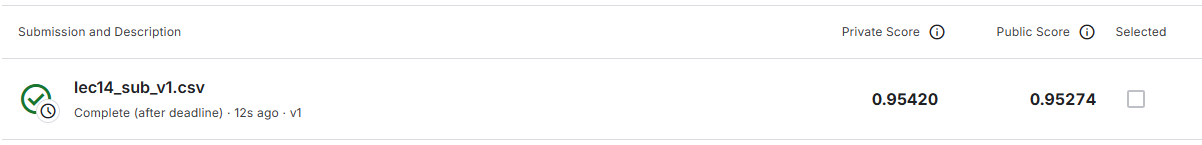

# **[10-1] 2차 모델튜닝**

In [45]:
# ========================================
# LightGBM 2차 GridSearchCV
# ========================================

X = train.drop(columns=['heart disease'])
y = train['heart disease']

lgb = LGBMClassifier(
    verbose=-1,
    random_state=1234
)

params = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 300],
    'num_leaves': [20, 31, 40]
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1234
)

grid = GridSearchCV(
    estimator=lgb,
    param_grid=params,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X, y)

print("최적 파라미터 :", grid.best_params_)
print("최고 ROC-AUC :", grid.best_score_)

최적 파라미터 : {'learning_rate': 0.1, 'n_estimators': 300, 'num_leaves': 20}
최고 ROC-AUC : 0.9551222138278466


# **[10-2] 모델변경**

In [46]:
# ========================================
# XGBoost 1차 GridSearchCV
# ========================================

from xgboost import XGBClassifier

X = train.drop(columns=['heart disease'])
y = train['heart disease']

xgb = XGBClassifier(
    random_state=1234,
    eval_metric='logloss'
)

params = {
    'learning_rate': [0.05, 0.1],
    'n_estimators': [200, 300],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1234
)

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X, y)

print("최적 파라미터 :", grid_xgb.best_params_)
print("최고 ROC-AUC :", grid_xgb.best_score_)

최적 파라미터 : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}
최고 ROC-AUC : 0.9552315476633586


# **[10-3] 모델결합_앙상블**

In [47]:
# ========================================
# LightGBM + XGBoost 앙상블
# ========================================

X = train.drop(columns=['heart disease'])
y = train['heart disease']

X_test = test.copy()

# LightGBM
lgb_best = LGBMClassifier(
    learning_rate=0.1,
    n_estimators=300,
    num_leaves=20,
    verbose=-1,
    random_state=1234
)

# XGBoost
xgb_best = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    random_state=1234,
    eval_metric='logloss'
)

# 학습
lgb_best.fit(X, y)
xgb_best.fit(X, y)

# 확률 예측
lgb_pred = lgb_best.predict_proba(X_test)[:, 0]
xgb_pred = xgb_best.predict_proba(X_test)[:, 0]

# 50 : 50 앙상블
ensemble_pred = (lgb_pred * 0.5) + (xgb_pred * 0.5)

# 제출 파일
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': ensemble_pred
})

submission.to_csv('lec14_sub_v2.csv', index=False)

print(submission.head())

       id  Heart Disease
0  630000       0.938653
1  630001       0.007745
2  630002       0.984947
3  630003       0.005429
4  630004       0.244849


# <font color=darkorange> **※SUB_V2----★※**
* 2910등
* 2775등

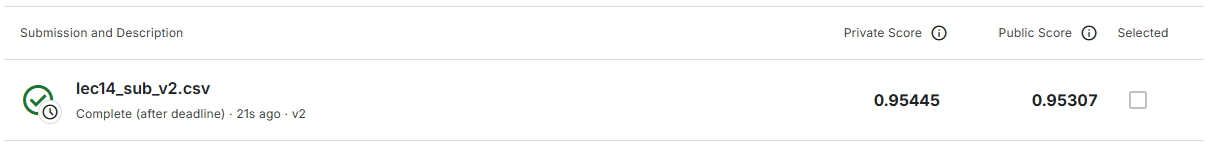

# **[11] 가중치 확인**
* 모델 결합 비율 재정리

In [49]:
# ========================================
# LightGBM + XGBoost 가중치 비교
# ========================================

X = train.drop(columns=['heart disease'])
y = train['heart disease']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1234,
    shuffle=True,
    stratify=y
)

# LightGBM
lgb_best = LGBMClassifier(
    learning_rate=0.1,
    n_estimators=300,
    num_leaves=20,
    verbose=-1,
    random_state=1234
)

# XGBoost
xgb_best = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    random_state=1234,
    eval_metric='logloss'
)

# 학습
lgb_best.fit(X_train, y_train)
xgb_best.fit(X_train, y_train)

# 검증 데이터 확률
# 현재 y=1은 Absence이므로 [:, 1] 사용
lgb_valid = lgb_best.predict_proba(X_valid)[:, 1]
xgb_valid = xgb_best.predict_proba(X_valid)[:, 1]

# 가중치별 ROC-AUC 비교
weights = [0, 0.25, 0.5, 0.75, 1.0]

for w in weights:
    ensemble_valid = (
        lgb_valid * (1 - w)
        + xgb_valid * w
    )

    score = roc_auc_score(y_valid, ensemble_valid)

    print(
        f"LightGBM {1-w:.2f} : XGBoost {w:.2f}"
        f" → ROC-AUC : {score:.6f}"
    )

LightGBM 1.00 : XGBoost 0.00 → ROC-AUC : 0.955005
LightGBM 0.75 : XGBoost 0.25 → ROC-AUC : 0.955103
LightGBM 0.50 : XGBoost 0.50 → ROC-AUC : 0.955156
LightGBM 0.25 : XGBoost 0.75 → ROC-AUC : 0.955164
LightGBM 0.00 : XGBoost 1.00 → ROC-AUC : 0.955127


In [51]:
# ========================================
# 최종 모델 학습
# LightGBM 25% + XGBoost 75%
# ========================================

X = train.drop(columns=['heart disease'])
y = train['heart disease']

X_test = test.copy()

# LightGBM
lgb_best = LGBMClassifier(
    learning_rate=0.1,
    n_estimators=300,
    num_leaves=20,
    verbose=-1,
    random_state=1234
)

# XGBoost
xgb_best = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    random_state=1234,
    eval_metric='logloss'
)

# 전체 데이터로 학습
lgb_best.fit(X, y)
xgb_best.fit(X, y)

# Kaggle 제출용
# 현재 Presence = 0 이므로 [:, 0]
lgb_pred = lgb_best.predict_proba(X_test)[:, 0]
xgb_pred = xgb_best.predict_proba(X_test)[:, 0]

# XGBoost 75% + LightGBM 25%
ensemble_pred = (
    lgb_pred * 0.25
    + xgb_pred * 0.75
)

# 제출 파일 생성
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': ensemble_pred
})

submission.to_csv(
    'lec14_sub_v3.csv',
    index=False
)

print(submission.head())

       id  Heart Disease
0  630000       0.944574
1  630001       0.007769
2  630002       0.985591
3  630003       0.005471
4  630004       0.244257


# <font color=darkorange> **※SUB_V3※**
* 2910등
* 2775등
* 2829등 ;;

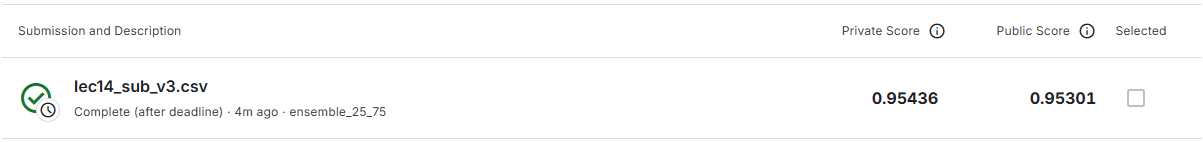